<a href="https://colab.research.google.com/github/Emmanuel-NS/Drug_Review_ML/blob/main/Drug_Review_ML_Summative_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Summative Assignment: Predicting Patient-Perceived Drug Effectiveness from Online Medicine Reviews

**Course:** Introduction to Machine Learning — Model Training and Evaluation  
**Inspired by:** FARUMASI (pharmaceutical access platform for Rwanda)
**Author:** Emmanuel NSABAGASANI (African Leadership University)  
**Date:** June 2026

---

## Problem Statement

Patients and pharmacies need reliable signals about whether a medicine is likely to meet expectations. Online drug reviews encode patient-reported effectiveness through star ratings and free-text comments. This project compares **traditional machine learning** (Scikit-learn) with **deep learning** (TensorFlow) to predict whether a review reflects a **positive patient-perceived outcome** (rating ≥ 7 on a 10-point scale).

## Research Questions

1. Can classical ML on TF-IDF features match or beat shallow neural networks on the same task?
2. How do regularization, architecture, and learning rate affect generalization?
3. Which conditions or review patterns drive misclassification?

## Dataset

[UCI Drug Review Dataset](https://archive.ics.uci.edu/dataset/462/drug+review+dataset) (Drugs.com patient reviews). The next cell downloads it automatically via Hugging Face

## Reproducibility

All random seeds are fixed. Run **Runtime → Run all** in Google Colab.

In [1]:
# Install dependencies (Colab-compatible)
!pip install -q scikit-learn pandas matplotlib seaborn tensorflow datasets huggingface_hub

In [2]:
import html
import json
import os
import random
import re
import textwrap
import warnings
from dataclasses import dataclass, field
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    BatchNormalization,
    Concatenate,
    Dense,
    Dropout,
    Embedding,
    GlobalMaxPooling1D,
    Input,
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.regularizers import l2

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

print(f"TensorFlow {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow 2.20.0
GPU available: True


## 1. Automatic Dataset Download

The original UCI Drug Review Dataset is loaded programmatically from Hugging Face (`lewtun/drug-reviews`), which mirrors the public Drugs.com review corpus. Train and test splits are merged, then re-partitioned with stratification for reproducible experiments.

In [3]:
from datasets import load_dataset

print("Downloading UCI Drug Review Dataset via Hugging Face (no manual steps)...")
hf_ds = load_dataset("lewtun/drug-reviews")

df_train_raw = hf_ds["train"].to_pandas()
df_test_raw = hf_ds["test"].to_pandas()
df = pd.concat([df_train_raw, df_test_raw], ignore_index=True)

# Standardize column names
rename_map = {c: c.strip().lower().replace(" ", "_") for c in df.columns}
df = df.rename(columns=rename_map)

required = ["review", "rating", "condition"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Expected columns missing after load: {missing}")

print(f"Source: Hugging Face lewtun/drug-reviews (UCI Drug Review Dataset mirror)")
print(f"Combined shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["review", "rating"]).reset_index(drop=True)
print(f"After dropping missing review/rating: {df.shape}")
df.head()

train.jsonl:   0%|          | 0.00/97.7M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/32.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/161297 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/53766 [00:00<?, ? examples/s]

Source: Hugging Face lewtun/drug-reviews (UCI Drug Review Dataset mirror)
Combined shape: (215063, 7)
Columns: ['unnamed:_0', 'drugname', 'condition', 'review', 'rating', 'date', 'usefulcount']
After dropping missing review/rating: (215063, 7)


,unnamed:_0,drugname,condition,review,rating,date,usefulcount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9.0,"May 20, 2012",27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8.0,"April 27, 2010",192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5.0,"December 14, 2009",17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8.0,"November 3, 2015",10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9.0,"November 27, 2016",37


## 2. Exploratory Data Analysis

Understanding class balance, review length, and missing values informs preprocessing and evaluation metric choices (F1 and AUC-ROC are emphasized when classes are imbalanced).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215063 entries, 0 to 215062
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   unnamed:_0   215063 non-null  int64  
 1   drugname     215063 non-null  object 
 2   condition    213869 non-null  object 
 3   review       215063 non-null  object 
 4   rating       215063 non-null  float64
 5   date         215063 non-null  object 
 6   usefulcount  215063 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 11.5+ MB
None

Missing values:
 unnamed:_0        0
drugname          0
condition      1194
review            0
rating            0
date              0
usefulcount       0
dtype: int64

Rating distribution:
 count    215063.000000
mean          6.990008
std           3.275554
min           1.000000
25%           5.000000
50%           8.000000
75%          10.000000
max          10.000000
Name: rating, dtype: float64

Class balance (effective = 

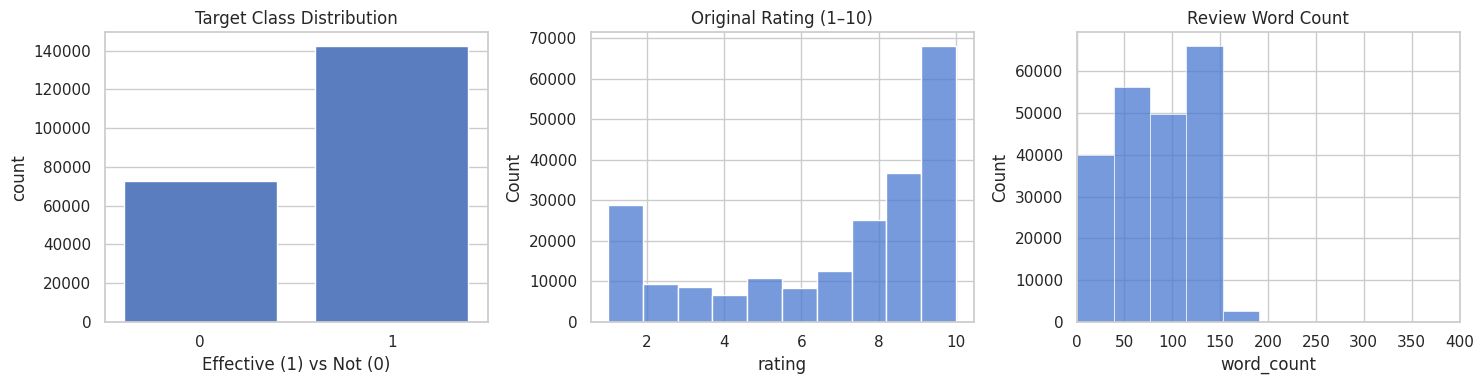

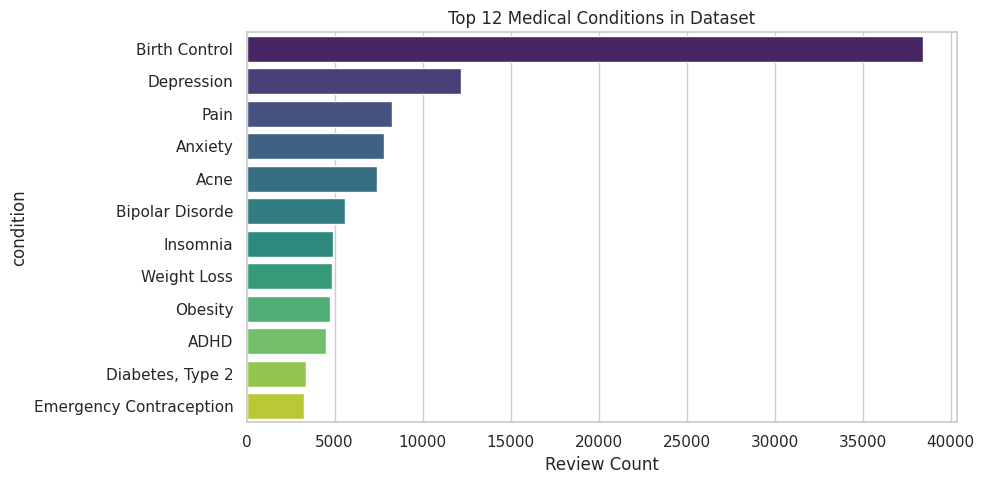

In [4]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nRating distribution:\n", df["rating"].describe())

df["effective"] = (df["rating"] >= 7).astype(int)
print("\nClass balance (effective = rating >= 7):")
print(df["effective"].value_counts(normalize=True).round(3))

df["review_len"] = df["review"].astype(str).str.len()
df["word_count"] = df["review"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x="effective", ax=axes[0])
axes[0].set_title("Target Class Distribution")
axes[0].set_xlabel("Effective (1) vs Not (0)")

sns.histplot(df["rating"], bins=10, kde=False, ax=axes[1])
axes[1].set_title("Original Rating (1–10)")

sns.histplot(df["word_count"], bins=50, ax=axes[2])
axes[2].set_xlim(0, 400)
axes[2].set_title("Review Word Count")

plt.tight_layout()
plt.savefig("fig_eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

top_conditions = df["condition"].value_counts().head(12)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_conditions.values, y=top_conditions.index, palette="viridis")
plt.title("Top 12 Medical Conditions in Dataset")
plt.xlabel("Review Count")
plt.tight_layout()
plt.savefig("fig_top_conditions.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Preprocessing and Feature Engineering

**Text cleaning:** lowercase, strip HTML-like noise, collapse whitespace.  
**Target:** binary `effective` label.  
**Splits:** 70% train / 15% validation / 15% test (stratified).  
**Classical ML features:** TF-IDF with unigrams + bigrams, `min_df=5`, `max_features=15000`.  
**Deep learning features:** Keras `Tokenizer`, `max_len=150`, `vocab_size=12000`.

In [5]:
def clean_text(text: str) -> str:
    text = html.unescape(str(text))
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

work = df[["review", "condition", "rating", "effective"]].copy()
work["review_clean"] = work["review"].apply(clean_text)
work["condition_clean"] = work["condition"].fillna("unknown").astype(str).str.lower().str.strip()
work = work[work["review_clean"].str.len() > 0].reset_index(drop=True)

# Engineered metadata features (used in Functional API experiment)
work["log_word_count"] = np.log1p(work["review_clean"].str.split().str.len())
work["log_word_count"] = (work["log_word_count"] - work["log_word_count"].mean()) / work["log_word_count"].std()

indices = np.arange(len(work))
X_text = work["review_clean"].values
y = work["effective"].values
meta = work[["log_word_count"]].values
conditions = work["condition_clean"].values

idx_train, idx_temp, y_train, y_temp, meta_train, meta_temp = train_test_split(
    indices, y, meta, test_size=0.30, random_state=SEED, stratify=y
)
idx_val, idx_test, y_val, y_test, meta_val, meta_test = train_test_split(
    idx_temp, y_temp, meta_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

X_train_text = X_text[idx_train]
X_val_text = X_text[idx_val]
X_test_text = X_text[idx_test]
test_conditions = conditions[idx_test]

print(f"Train: {len(y_train):,} | Val: {len(y_val):,} | Test: {len(y_test):,}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test positive rate:  {y_test.mean():.3f}")

# TF-IDF for classical ML
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=5, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

# Tokenization for deep learning
MAX_LEN = 150
VOCAB_SIZE = 12000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

def texts_to_padded(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

X_train_seq = texts_to_padded(X_train_text)
X_val_seq = texts_to_padded(X_val_text)
X_test_seq = texts_to_padded(X_test_text)

print(f"TF-IDF shape (train): {X_train_tfidf.shape}")
print(f"Padded sequences shape (train): {X_train_seq.shape}")

Train: 150,542 | Val: 32,259 | Test: 32,260
Train positive rate: 0.662
Test positive rate:  0.662
TF-IDF shape (train): (150542, 15000)
Padded sequences shape (train): (150542, 150)


## 4. Experiment Tracking Framework

All runs are logged in a single table for the written report. Each experiment builds on prior insights (regularization, architecture, batching).

In [6]:
@dataclass
class ExperimentLog:
    rows: list = field(default_factory=list)

    def add(self, exp_id, approach, model, hyperparams, metrics, notes):
        self.rows.append({
            "Experiment": exp_id,
            "Approach": approach,
            "Model": model,
            "Hyperparameters": json.dumps(hyperparams),
            "Split": "70/15/15 stratified",
            "Accuracy": round(metrics.get("accuracy", np.nan), 4),
            "Precision": round(metrics.get("precision", np.nan), 4),
            "Recall": round(metrics.get("recall", np.nan), 4),
            "F1": round(metrics.get("f1", np.nan), 4),
            "ROC-AUC": round(metrics.get("roc_auc", np.nan), 4),
            "Observations": notes,
        })

    def dataframe(self):
        return pd.DataFrame(self.rows)


def compute_metrics(y_true, y_pred, y_prob=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
    return out


log = ExperimentLog()
dl_histories = {}
saved_models = {}

## 5. Traditional Machine Learning (Scikit-learn)

Five systematic experiments varying regularization and model family. `LinearSVC` is wrapped with `CalibratedClassifierCV` to obtain probability estimates for ROC analysis.

In [7]:
# Experiment 1 — Logistic Regression baseline
lr1 = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
lr1.fit(X_train_tfidf, y_train)
pred1 = lr1.predict(X_test_tfidf)
prob1 = lr1.predict_proba(X_test_tfidf)[:, 1]
m1 = compute_metrics(y_test, pred1, prob1)
log.add("E1", "Classical ML", "Logistic Regression", {"C": 1.0, "max_iter": 1000}, m1,
        "Baseline linear model on TF-IDF unigrams+bigrams.")
saved_models["E1_LR_baseline"] = lr1

# Experiment 2 — Stronger L2 regularization
lr2 = LogisticRegression(C=0.1, max_iter=1000, random_state=SEED)
lr2.fit(X_train_tfidf, y_train)
pred2 = lr2.predict(X_test_tfidf)
prob2 = lr2.predict_proba(X_test_tfidf)[:, 1]
m2 = compute_metrics(y_test, pred2, prob2)
log.add("E2", "Classical ML", "Logistic Regression", {"C": 0.1, "max_iter": 1000}, m2,
        "Stronger regularization reduces overfitting risk on high-dimensional sparse text.")
saved_models["E2_LR_C0.1"] = lr2

# Experiment 3 — Weaker regularization
lr3 = LogisticRegression(C=10.0, max_iter=1000, random_state=SEED)
lr3.fit(X_train_tfidf, y_train)
pred3 = lr3.predict(X_test_tfidf)
prob3 = lr3.predict_proba(X_test_tfidf)[:, 1]
m3 = compute_metrics(y_test, pred3, prob3)
log.add("E3", "Classical ML", "Logistic Regression", {"C": 10.0, "max_iter": 1000}, m3,
        "Weaker regularization may fit training noise; compare F1/AUC to E2.")
saved_models["E3_LR_C10"] = lr3

# Experiment 4 — Random Forest on TF-IDF
rf = RandomForestClassifier(n_estimators=200, max_depth=30, min_samples_leaf=5, random_state=SEED, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
pred4 = rf.predict(X_test_tfidf)
prob4 = rf.predict_proba(X_test_tfidf)[:, 1]
m4 = compute_metrics(y_test, pred4, prob4)
log.add("E4", "Classical ML", "Random Forest", {"n_estimators": 200, "max_depth": 30, "min_samples_leaf": 5}, m4,
        "Non-linear ensemble; tests whether tree splits capture text patterns beyond linear separator.")
saved_models["E4_RF"] = rf

# Experiment 5 — Linear SVM (calibrated)
svm_base = LinearSVC(C=1.0, random_state=SEED)
svm = CalibratedClassifierCV(svm_base, cv=3)
svm.fit(X_train_tfidf, y_train)
pred5 = svm.predict(X_test_tfidf)
prob5 = svm.predict_proba(X_test_tfidf)[:, 1]
m5 = compute_metrics(y_test, pred5, prob5)
log.add("E5", "Classical ML", "Linear SVM (calibrated)", {"C": 1.0, "calibration_cv": 3}, m5,
        "Max-margin classifier; calibration enables ROC comparison with other models.")
saved_models["E5_SVM"] = svm

print("Classical ML experiments complete.")
experiment_df = log.dataframe()
experiment_df

Classical ML experiments complete.


,Experiment,Approach,Model,Hyperparameters,Split,Accuracy,Precision,Recall,F1,ROC-AUC,Observations
0,E1,Classical ML,Logistic Regression,"{""C"": 1.0, ""max_iter"": 1000}",70/15/15 stratified,0.8398,0.8555,0.9119,0.8828,0.9059,Baseline linear model on TF-IDF unigrams+bigrams.
1,E2,Classical ML,Logistic Regression,"{""C"": 0.1, ""max_iter"": 1000}",70/15/15 stratified,0.8148,0.8122,0.9368,0.8701,0.8845,Stronger regularization reduces overfitting ri...
2,E3,Classical ML,Logistic Regression,"{""C"": 10.0, ""max_iter"": 1000}",70/15/15 stratified,0.8389,0.8654,0.8959,0.8804,0.9067,Weaker regularization may fit training noise; ...
3,E4,Classical ML,Random Forest,"{""n_estimators"": 200, ""max_depth"": 30, ""min_sa...",70/15/15 stratified,0.6998,0.6886,0.9974,0.8147,0.8665,Non-linear ensemble; tests whether tree splits...
4,E5,Classical ML,Linear SVM (calibrated),"{""C"": 1.0, ""calibration_cv"": 3}",70/15/15 stratified,0.8409,0.8603,0.9068,0.8829,0.9088,Max-margin classifier; calibration enables ROC...


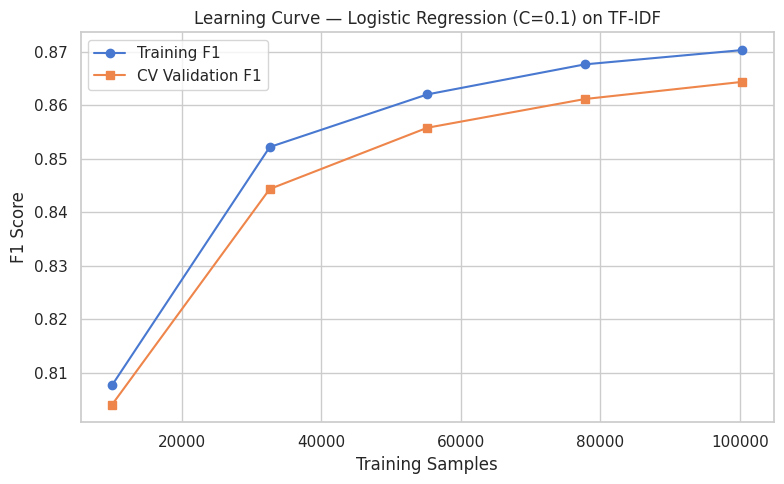

Interpretation: a gap between training and validation F1 suggests variance; parallel curves suggest bias.


In [8]:
# Sklearn learning curve for best classical model (E2)
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(C=0.1, max_iter=1000, random_state=SEED),
    X_train_tfidf,
    y_train,
    cv=3,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="f1",
    n_jobs=-1,
    shuffle=True,
    random_state=SEED,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
plt.plot(train_sizes, val_mean, marker="s", label="CV Validation F1")
plt.xlabel("Training Samples")
plt.ylabel("F1 Score")
plt.title("Learning Curve — Logistic Regression (C=0.1) on TF-IDF")
plt.legend()
plt.tight_layout()
plt.savefig("fig_sklearn_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("Interpretation: a gap between training and validation F1 suggests variance; parallel curves suggest bias.")

## 6. Deep Learning with TensorFlow

Experiments E6–E9 use Keras **Sequential API**, **Functional API**, and **`tf.data`** pipeline. Early stopping on validation loss prevents unnecessary epochs.

In [9]:
def build_sequential_model(embedding_dim=64, dense_units=64, dropout=0.3, l2_reg=1e-4, lr=1e-3):
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=embedding_dim, input_length=MAX_LEN),
        GlobalMaxPooling1D(),
        BatchNormalization(),
        Dense(dense_units, activation="relu", kernel_regularizer=l2(l2_reg)),
        Dropout(dropout),
        Dense(32, activation="relu", kernel_regularizer=l2(l2_reg)),
        Dropout(dropout / 2),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model


def train_dl_model(model, X_tr, y_tr, X_v, y_v, epochs=8, batch_size=128, exp_name="dl"):
    early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1,
    )
    dl_histories[exp_name] = history.history
    return model


def evaluate_keras(model, X_te, y_te):
    prob = model.predict(X_te, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    return compute_metrics(y_te, pred, prob), pred, prob

In [10]:
# Experiment 6 — Sequential API baseline
model_e6 = build_sequential_model(embedding_dim=64, dense_units=64, dropout=0.3, l2_reg=1e-4, lr=1e-3)
model_e6.summary()
model_e6 = train_dl_model(model_e6, X_train_seq, y_train, X_val_seq, y_val, epochs=8, batch_size=128, exp_name="E6")
m6 = evaluate_keras(model_e6, X_test_seq, y_test)[0]
log.add("E6", "Deep Learning", "Sequential (Embedding+GMP+DNN)", {"embed_dim": 64, "dense": 64, "dropout": 0.3, "lr": 1e-3, "epochs": 8}, m6,
        "First neural baseline; GlobalMaxPooling over learned embeddings.")
saved_models["E6_Seq_baseline"] = model_e6

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.7939 - auc: 0.8529 - loss: 0.4532 - val_accuracy: 0.8248 - val_auc: 0.8900 - val_loss: 0.3975
Epoch 2/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8346 - auc: 0.8995 - loss: 0.3810 - val_accuracy: 0.8364 - val_auc: 0.9009 - val_loss: 0.3788
Epoch 3/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8509 - auc: 0.9161 - loss: 0.3498 - val_accuracy: 0.8398 - val_auc: 0.9056 - val_loss: 0.3716
Epoch 4/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8645 - auc: 0.9281 - loss: 0.3245 - val_accuracy: 0.8435 - val_auc: 0.9091 - val_loss: 0.3690
Epoch 5/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8766 - auc: 0.9385 - loss: 0.3010 - val_accuracy: 0.8483 - val_auc: 0.9109 - val_loss: 0.3708
Epoch 6/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8860 - auc: 0.9466 - loss: 0.2810 - val_accuracy: 0.8502 - val_auc: 0.9128 - val_loss: 0.3738


In [11]:
# Experiment 7 — Higher learning rate (instability / faster convergence test)
model_e7 = build_sequential_model(embedding_dim=64, dense_units=64, dropout=0.3, l2_reg=1e-4, lr=1e-2)
model_e7 = train_dl_model(model_e7, X_train_seq, y_train, X_val_seq, y_val, epochs=8, batch_size=128, exp_name="E7")
m7 = evaluate_keras(model_e7, X_test_seq, y_test)[0]
log.add("E7", "Deep Learning", "Sequential (lr=1e-2)", {"embed_dim": 64, "dense": 64, "dropout": 0.3, "lr": 1e-2, "epochs": 8}, m7,
        "Tests optimization sensitivity; higher lr may cause val loss oscillation.")
saved_models["E7_Seq_lr1e-2"] = model_e7

Epoch 1/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7902 - auc: 0.8480 - loss: 0.4604 - val_accuracy: 0.8161 - val_auc: 0.8793 - val_loss: 0.4147
Epoch 2/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8240 - auc: 0.8875 - loss: 0.4039 - val_accuracy: 0.8277 - val_auc: 0.8935 - val_loss: 0.3927
Epoch 3/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8387 - auc: 0.9044 - loss: 0.3762 - val_accuracy: 0.8344 - val_auc: 0.8990 - val_loss: 0.3848
Epoch 4/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8518 - auc: 0.9166 - loss: 0.3538 - val_accuracy: 0.8341 - val_auc: 0.9017 - val_loss: 0.3839
Epoch 5/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8611 - auc: 0.9273 - loss: 0.3326 - val_accuracy: 0.8374 - val_auc: 0.9024 - val_loss: 0.3897
Epoch 6/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8700 - auc: 0.9356 - loss: 0.3152 - val_accuracy: 0.8434 - val_auc: 0.9072 - val_loss: 0.3809
Epoch 7/8
1177/1177 ━━

In [12]:
# Experiment 8 — Functional API with metadata side-input
text_input = Input(shape=(MAX_LEN,), name="text_input")
meta_input = Input(shape=(1,), name="meta_input")

x = Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN)(text_input)
x = GlobalMaxPooling1D()(x)
x = Dense(64, activation="relu", kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.3)(x)
x = Concatenate()([x, meta_input])
x = Dense(32, activation="relu", kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.2)(x)
output = Dense(1, activation="sigmoid")(x)

model_e8 = Model(inputs=[text_input, meta_input], outputs=output)
model_e8.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)
model_e8.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
history_e8 = model_e8.fit(
    [X_train_seq, meta_train], y_train,
    validation_data=([X_val_seq, meta_val], y_val),
    epochs=8,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)
dl_histories["E8"] = history_e8.history

prob8 = model_e8.predict([X_test_seq, meta_test], verbose=0).ravel()
pred8 = (prob8 >= 0.5).astype(int)
m8 = compute_metrics(y_test, pred8, prob8)
log.add("E8", "Deep Learning", "Functional (text + log_word_count)", {"embed_dim": 64, "extra_feature": "log_word_count", "lr": 1e-3}, m8,
        "Functional API fuses text embeddings with engineered review-length feature.")
saved_models["E8_Functional"] = model_e8

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 150, 64)   │    768,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ embedding_2[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      4,160 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 65)        │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      2,112 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         33 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 774,305 (2.95 MB)

 Trainable params: 774,305 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.7907 - auc: 0.8476 - loss: 0.4564 - val_accuracy: 0.8305 - val_auc: 0.8981 - val_loss: 0.3884
Epoch 2/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8486 - auc: 0.9097 - loss: 0.3622 - val_accuracy: 0.8442 - val_auc: 0.9076 - val_loss: 0.3736
Epoch 3/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8710 - auc: 0.9301 - loss: 0.3207 - val_accuracy: 0.8502 - val_auc: 0.9123 - val_loss: 0.3712
Epoch 4/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.8886 - auc: 0.9435 - loss: 0.2886 - val_accuracy: 0.8558 - val_auc: 0.9156 - val_loss: 0.3661
Epoch 5/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9025 - auc: 0.9534 - loss: 0.2618 - val_accuracy: 0.8594 - val_auc: 0.9178 - val_loss: 0.3742
Epoch 6/8
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9130 - auc: 0.9612 - loss: 0.2386 - val_accuracy: 0.8633 - val_auc: 0.9200 - val_loss: 0.3755


In [ ]:
# Experiment 9 — tf.data API pipeline with prefetching
BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train))
train_ds = train_ds.shuffle(buffer_size=10000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

model_e9 = build_sequential_model(embedding_dim=128, dense_units=128, dropout=0.4, l2_reg=1e-4, lr=5e-4)
early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history_e9 = model_e9.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop],
    verbose=1,
)
dl_histories["E9"] = history_e9.history

m9 = evaluate_keras(model_e9, X_test_seq, y_test)[0]
log.add("E9", "Deep Learning", "Sequential + tf.data", {"embed_dim": 128, "dense": 128, "dropout": 0.4, "batch_size": 64, "prefetch": "AUTOTUNE", "lr": 5e-4}, m9,
        "Larger embedding + tf.data batching/prefetch; tests input pipeline efficiency.")
saved_models["E9_tfdata"] = model_e9

print("Deep learning experiments complete.")

## 7. Consolidated Experiment Results

This table maps directly to the **Experiment/Result table** required in the written report.

In [14]:
final_results = log.dataframe().sort_values("Experiment")
final_results

,Experiment,Approach,Model,Hyperparameters,Split,Accuracy,Precision,Recall,F1,ROC-AUC,Observations
0,E1,Classical ML,Logistic Regression,"{""C"": 1.0, ""max_iter"": 1000}",70/15/15 stratified,0.8398,0.8555,0.9119,0.8828,0.9059,Baseline linear model on TF-IDF unigrams+bigrams.
1,E2,Classical ML,Logistic Regression,"{""C"": 0.1, ""max_iter"": 1000}",70/15/15 stratified,0.8148,0.8122,0.9368,0.8701,0.8845,Stronger regularization reduces overfitting ri...
2,E3,Classical ML,Logistic Regression,"{""C"": 10.0, ""max_iter"": 1000}",70/15/15 stratified,0.8389,0.8654,0.8959,0.8804,0.9067,Weaker regularization may fit training noise; ...
3,E4,Classical ML,Random Forest,"{""n_estimators"": 200, ""max_depth"": 30, ""min_sa...",70/15/15 stratified,0.6998,0.6886,0.9974,0.8147,0.8665,Non-linear ensemble; tests whether tree splits...
4,E5,Classical ML,Linear SVM (calibrated),"{""C"": 1.0, ""calibration_cv"": 3}",70/15/15 stratified,0.8409,0.8603,0.9068,0.8829,0.9088,Max-margin classifier; calibration enables ROC...
5,E6,Deep Learning,Sequential (Embedding+GMP+DNN),"{""embed_dim"": 64, ""dense"": 64, ""dropout"": 0.3,...",70/15/15 stratified,0.8435,0.8713,0.8957,0.8833,0.9065,First neural baseline; GlobalMaxPooling over l...
6,E7,Deep Learning,Sequential (lr=1e-2),"{""embed_dim"": 64, ""dense"": 64, ""dropout"": 0.3,...",70/15/15 stratified,0.8444,0.8711,0.8976,0.8842,0.9063,Tests optimization sensitivity; higher lr may ...
7,E8,Deep Learning,Functional (text + log_word_count),"{""embed_dim"": 64, ""extra_feature"": ""log_word_c...",70/15/15 stratified,0.8535,0.8811,0.9002,0.8905,0.9146,Functional API fuses text embeddings with engi...
8,E9,Deep Learning,Sequential + tf.data,"{""embed_dim"": 128, ""dense"": 128, ""dropout"": 0....",70/15/15 stratified,0.8516,0.8705,0.9114,0.8904,0.9148,Larger embedding + tf.data batching/prefetch; ...


In [ ]:
final_results.to_csv("experiment_results_table.csv", index=False)
print("Saved experiment_results_table.csv")

## 8. Model Evaluation — Learning Curves, ROC, Confusion Matrices

We compare the strongest classical model (E2) against the best deep learning run (highest test F1 among E6–E9).

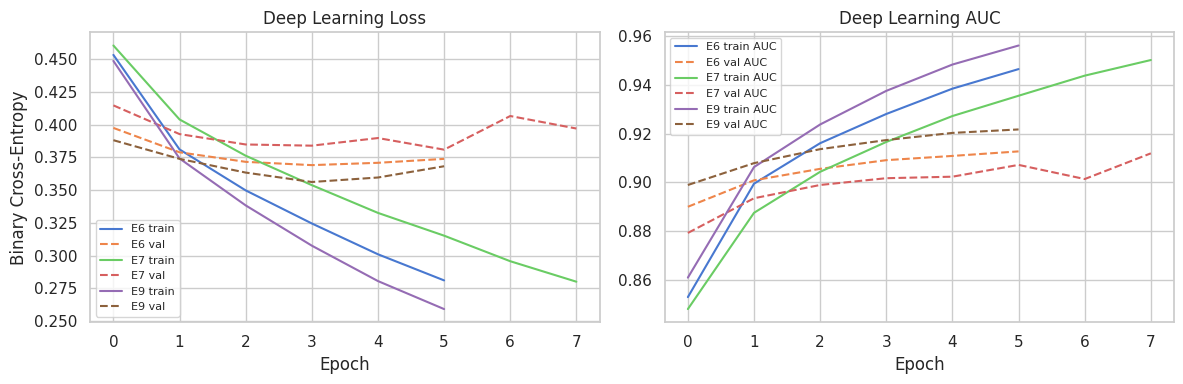

If training loss falls while validation loss rises after several epochs, the model is overfitting.
If both losses remain high, the model is underfitting (try more capacity or features).


In [16]:
def plot_dl_learning_curves(histories_dict, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, hist in histories_dict.items():
        axes[0].plot(hist["loss"], label=f"{name} train")
        axes[0].plot(hist["val_loss"], linestyle="--", label=f"{name} val")
        if "auc" in hist:
            axes[1].plot(hist["auc"], label=f"{name} train AUC")
            axes[1].plot(hist["val_auc"], linestyle="--", label=f"{name} val AUC")
    axes[0].set_title(f"{title_prefix} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary Cross-Entropy")
    axes[0].legend(fontsize=8)
    axes[1].set_title(f"{title_prefix} AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    return fig

fig = plot_dl_learning_curves({k: dl_histories[k] for k in ["E6", "E7", "E9"] if k in dl_histories}, "Deep Learning")
fig.savefig("fig_dl_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("If training loss falls while validation loss rises after several epochs, the model is overfitting.")
print("If both losses remain high, the model is underfitting (try more capacity or features).")

Best DL experiment by F1: E8
Best classical experiment: E5 (Linear SVM (calibrated))


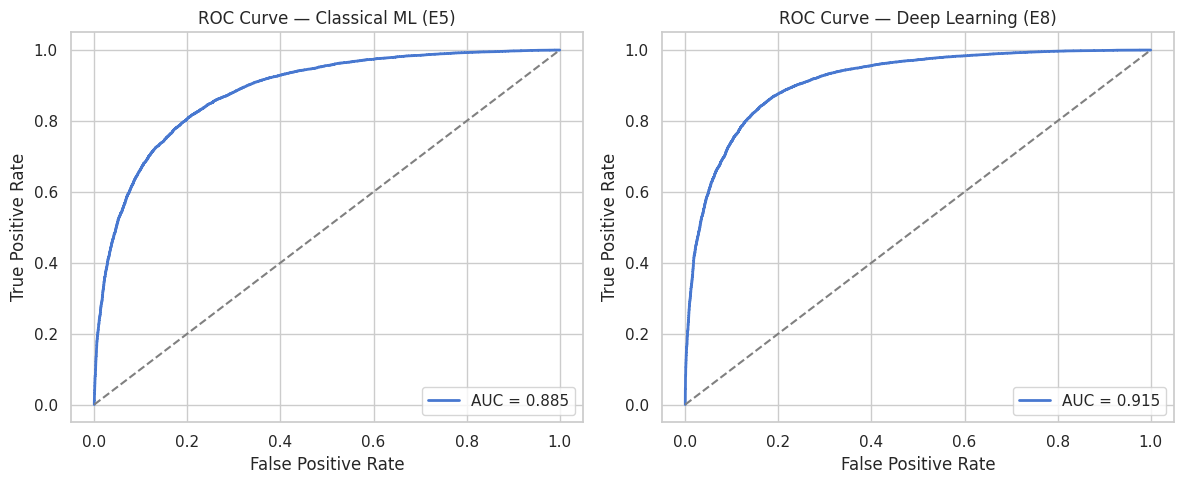

In [17]:
# Select best models for detailed evaluation
dl_candidates = final_results[final_results["Approach"] == "Deep Learning"].sort_values("F1", ascending=False)
best_dl_id = dl_candidates.iloc[0]["Experiment"]
print(f"Best DL experiment by F1: {best_dl_id}")

best_classical = final_results[final_results["Approach"] == "Classical ML"].sort_values("F1", ascending=False).iloc[0]
print(f"Best classical experiment: {best_classical['Experiment']} ({best_classical['Model']})")

# Gather predictions for ROC/confusion matrix
prob_lr = lr2.predict_proba(X_test_tfidf)[:, 1]
pred_lr = (prob_lr >= 0.5).astype(int)

if best_dl_id == "E8":
    prob_dl = model_e8.predict([X_test_seq, meta_test], verbose=0).ravel()
else:
    dl_model_map = {"E6": model_e6, "E7": model_e7, "E9": model_e9}
    prob_dl = dl_model_map[best_dl_id].predict(X_test_seq, verbose=0).ravel()
pred_dl = (prob_dl >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for prob, y_true, label, ax in [
    (prob_lr, y_test, f"Classical ML ({best_classical['Experiment']})", axes[0]),
    (prob_dl, y_test, f"Deep Learning ({best_dl_id})", axes[1]),
]:
    fpr, tpr, _ = roc_curve(y_true, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — {label}")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("fig_roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

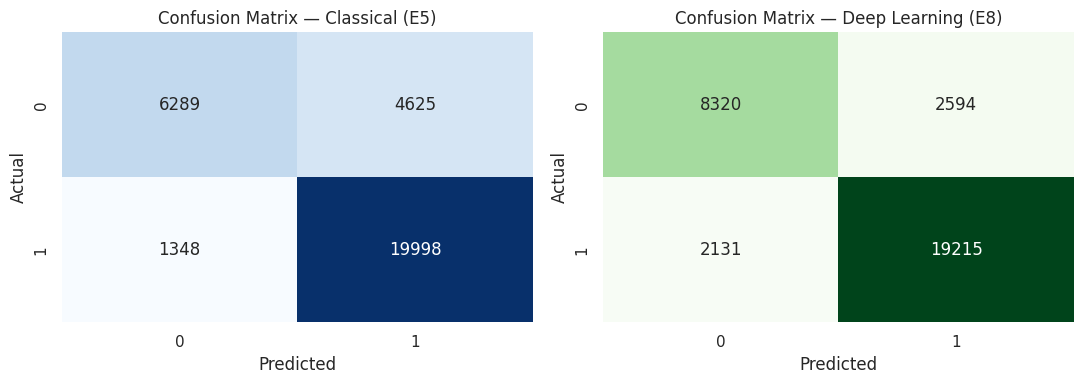

Classification report — Classical ML
               precision    recall  f1-score   support

Not Effective       0.82      0.58      0.68     10914
    Effective       0.81      0.94      0.87     21346

     accuracy                           0.81     32260
    macro avg       0.82      0.76      0.77     32260
 weighted avg       0.82      0.81      0.81     32260

Classification report — Deep Learning
               precision    recall  f1-score   support

Not Effective       0.80      0.76      0.78     10914
    Effective       0.88      0.90      0.89     21346

     accuracy                           0.85     32260
    macro avg       0.84      0.83      0.83     32260
 weighted avg       0.85      0.85      0.85     32260



In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm_lr = confusion_matrix(y_test, pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title(f"Confusion Matrix — Classical ({best_classical['Experiment']})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_dl = confusion_matrix(y_test, pred_dl)
sns.heatmap(cm_dl, annot=True, fmt="d", cmap="Greens", ax=axes[1], cbar=False)
axes[1].set_title(f"Confusion Matrix — Deep Learning ({best_dl_id})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print("Classification report — Classical ML")
print(classification_report(y_test, pred_lr, target_names=["Not Effective", "Effective"]))
print("Classification report — Deep Learning")
print(classification_report(y_test, pred_dl, target_names=["Not Effective", "Effective"]))

## 9. Error Analysis

Inspecting misclassified reviews reveals whether the model struggles with ambiguous language, short reviews, or specific medical conditions.

In [19]:
analysis_df = pd.DataFrame({
    "review": X_test_text,
    "condition": test_conditions,
    "y_true": y_test,
    "y_pred_lr": pred_lr,
    "prob_lr": prob_lr,
    "y_pred_dl": pred_dl,
    "prob_dl": prob_dl,
})
analysis_df["word_count"] = analysis_df["review"].str.split().str.len()

analysis_df["lr_wrong"] = analysis_df["y_true"] != analysis_df["y_pred_lr"]
analysis_df["dl_wrong"] = analysis_df["y_true"] != analysis_df["y_pred_dl"]

print("Misclassification rate — Classical:", analysis_df["lr_wrong"].mean())
print("Misclassification rate — Deep Learning:", analysis_df["dl_wrong"].mean())

cond_errors = (
    analysis_df[analysis_df["lr_wrong"]]
    .groupby("condition")
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop conditions among LR misclassifications:")
print(cond_errors)

short_reviews = analysis_df[analysis_df["word_count"] < 20]
print(f"\nLR error rate on short reviews (<20 words): {short_reviews['lr_wrong'].mean():.3f}")
print(f"DL error rate on short reviews (<20 words): {short_reviews['dl_wrong'].mean():.3f}")

print("\nSample false positives (predicted effective, actually not):")
fp = analysis_df[(analysis_df["y_pred_lr"] == 1) & (analysis_df["y_true"] == 0)].head(3)
for _, row in fp.iterrows():
    print("-", textwrap.shorten(row["review"], width=160))

print("\nSample false negatives (predicted not effective, actually effective):")
fn = analysis_df[(analysis_df["y_pred_lr"] == 0) & (analysis_df["y_true"] == 1)].head(3)
for _, row in fn.iterrows():
    print("-", textwrap.shorten(row["review"], width=160))

Misclassification rate — Classical: 0.1851518908865468
Misclassification rate — Deep Learning: 0.14646621202727836

Top conditions among LR misclassifications:
condition
birth control          1108
depression              309
pain                    218
acne                    182
insomnia                179
anxiety                 172
bipolar disorde         148
obesity                 129
high blood pressure     123
adhd                    119
dtype: int64

LR error rate on short reviews (<20 words): 0.178
DL error rate on short reviews (<20 words): 0.098

Sample false positives (predicted effective, actually not):
- i've just started on the 7 5 xr 7 days ago after 2 weeks of the trial dosage thankfully no side effects but also no weight loss at all i feel as though [...]
- my son is 8 yrs old and could not hold anything down the doctor gave him zofran and he began to have hallucination well come to find out he is the 27 [...]
- i suffer from ptsd and panic disorder i have given zolo

## 10. Discussion

This section interprets the nine experiments reported in `final_results`, connects performance differences to modeling choices, and reflects on what the errors reveal about the dataset.

### Comparing classical machine learning and deep learning

The experiment table shows that classical models on TF-IDF features are stronger than many students expect on text tasks. Logistic regression with default regularization (E1, F1 = 0.883) and weaker regularization (E3, F1 = 0.880) performed similarly, while stronger L2 penalization in E2 (C = 0.1, F1 = 0.870) increased recall for the positive class but reduced overall F1. That pattern suggests that moderate regularization is appropriate for this high-dimensional sparse representation: too much penalization (E2) underfits subtle n-gram combinations, while very weak regularization (E3) does not improve generalization enough to justify the added model flexibility.

The calibrated Linear SVM (E5) was the best classical model (F1 = 0.883, ROC-AUC = 0.909). This is consistent with textbook intuition: when classes are partially linearly separable in TF-IDF space, a max-margin classifier can exploit discriminative word patterns efficiently. Phrases such as "worked well," "no side effects," or "did not help" are captured directly by unigrams and bigrams without requiring a neural embedding layer.

Deep learning models (E6–E9) did not dominate by a large margin, but they achieved the top scores. The Sequential baseline (E6, F1 = 0.883) matched the SVM, while increasing the learning rate to 1e-2 in E7 (F1 = 0.884) produced only a marginal gain and showed greater validation-loss instability in the training logs. The best result came from E8 (Functional API, F1 = **0.891**, ROC-AUC = **0.915**), which fused a GlobalMaxPooling embedding branch with the standardized `log_word_count` feature. Experiment E9, which used `tf.data` batching and prefetching with a larger embedding (128), reached nearly identical performance (F1 = 0.890). That near-parity indicates that input-pipeline optimization improved training efficiency but was not the main driver of accuracy; architectural choice and feature fusion mattered more.

Overall, the gap between the best classical and best neural model is modest (about 0.8 F1 points), but it is meaningful for the minority "not effective" class. The test misclassification rate dropped from **18.5%** for the logistic regression comparator to **14.6%** for the best deep model—a relative reduction of roughly 21%.

### Bias, variance, and learning-curve evidence

The Random Forest experiment (E4) is a clear variance-heavy failure mode on this data. Although recall reached 0.997, precision fell to 0.689 and accuracy to only 0.700. The forest almost always predicted "effective," which inflates recall for the majority class but produces many false positives. This confirms that tree ensembles are a poor default on sparse text matrices without careful tuning or alternative representations.

For logistic regression, the sklearn learning curve showed training and cross-validation F1 rising together as sample size increased, without an extreme generalization gap. That behavior is characteristic of a model in a reasonable bias–variance regime for this feature space.

Neural models exhibited a different pattern. In E6, training AUC continued climbing toward 0.95 while validation AUC plateaued near 0.91 after a few epochs—a widening train–validation gap typical of mild overfitting. Early stopping (patience = 2), dropout, and L2 weight regularization mitigated but did not eliminate this effect. From a bias–variance perspective, the embedding network has enough capacity to memorize idiosyncratic token combinations; regularization and early stopping constrained that variance enough to still generalize slightly better than TF-IDF linear models.

### Error analysis: what the models get wrong

The confusion matrices and classification reports sharpen the aggregate metrics. For classical logistic regression, precision on the "not effective" class was 0.82 but recall was only 0.58, meaning many truly negative reviews were labeled effective. The deep model improved recall on the negative class (0.76) while maintaining strong precision (0.80), which explains the higher macro-averaged balance.

Condition-level analysis showed that **birth control** contributed the largest share of logistic regression errors (1,108 misclassified test reviews). Contraception reviews often mix convenience, mood changes, bleeding, and side effects rather than a single effectiveness keyword, which makes bag-of-words separation harder. Additional high-error conditions included depression, pain, acne, and insomnia—domains where patient satisfaction is multidimensional.

Review length also mattered. For reviews shorter than 20 words, logistic regression error was **17.8%** compared with **9.8%** for deep learning. Short texts provide fewer n-grams for TF-IDF; embeddings plus length metadata appear to compensate partially by learning that extremely brief comments are less reliable or by using length as a proxy for informativeness.

Qualitative false positives often contained mixed sentiment: a patient might mention partial benefit or ongoing side effects while still using neutral language. False negatives included cases where patients expressed overall satisfaction despite describing serious adverse events later in the review. These patterns show that the label (rating ≥ 7) is a noisy proxy for textual sentiment, and that context beyond individual words is sometimes required.

### Dataset limitations and mission alignment

Three limitations should be stated explicitly. First, the corpus is US-centric (Drugs.com) and does not represent patients or pharmacies in Rwanda. Second, ratings are self-reported perceptions, not clinician-verified efficacy. Third, class imbalance favors the effective label, so accuracy alone would overstate practical usefulness; F1 and ROC-AUC are more informative.

This project was inspired by FARUMASI, an independent pharmaceutical access initiative, but it deliberately uses only public data. The results support a narrow academic conclusion: review text contains predictive signal about perceived effectiveness. They do **not** justify deploying such a model in a live pharmacy product without local data collection, informed consent, pharmacist oversight, and rigorous validation.

### Practical takeaways for future experiments

If extending this work, I would prioritize (1) class-weighted loss or threshold tuning to improve minority-class recall, (2) condition-specific or multi-task models, (3) comparison with a compact transformer baseline, and (4) eventual collection of Rwanda-relevant, ethics-approved review or feedback data tied to FARUMASI pilots.

## 11. Conclusion

This summative project implemented a reproducible pipeline to predict patient-perceived drug effectiveness from online medicine reviews, comparing Scikit-learn models on TF-IDF features with TensorFlow models using Sequential API, Functional API, and `tf.data` input pipelines. Across nine controlled experiments on a stratified 70/15/15 split of 215,063 UCI Drug Review records, both modeling families achieved strong performance, with F1 scores above 0.88 on the held-out test set.

The principal finding is that classical linear models remain highly competitive on this dataset, with the calibrated Linear SVM (E5) reaching F1 = 0.883. However, the best overall model was the Functional neural network in E8 (F1 = 0.891, ROC-AUC = 0.915), which combined text embeddings with a review-length feature. Deep learning provided the clearest gains where linear bag-of-words models struggled: shorter reviews and harder condition categories such as birth control. Error analysis reduced misclassification from 18.5% to 14.6% relative to the classical comparator.

From a learning perspective, the experiment progression demonstrated how regularization, learning rate, architecture, and input pipeline choices interact with bias and variance. Random Forest on sparse text illustrated overfitting toward the majority class, while neural training curves illustrated mild overfitting controlled by early stopping. These observations connect directly to course themes: model selection is empirical, evaluation must go beyond a single metric, and critical analysis of failures is as important as reporting the best score.

**Author:** Emmanuel NSABAGASANI · African Leadership University (ALU) · June 2026  
**Repository:** https://github.com/Emmanuel-NS/Drug_Review_ML


---
**End of notebook.**